## 1. Architecture Diagram

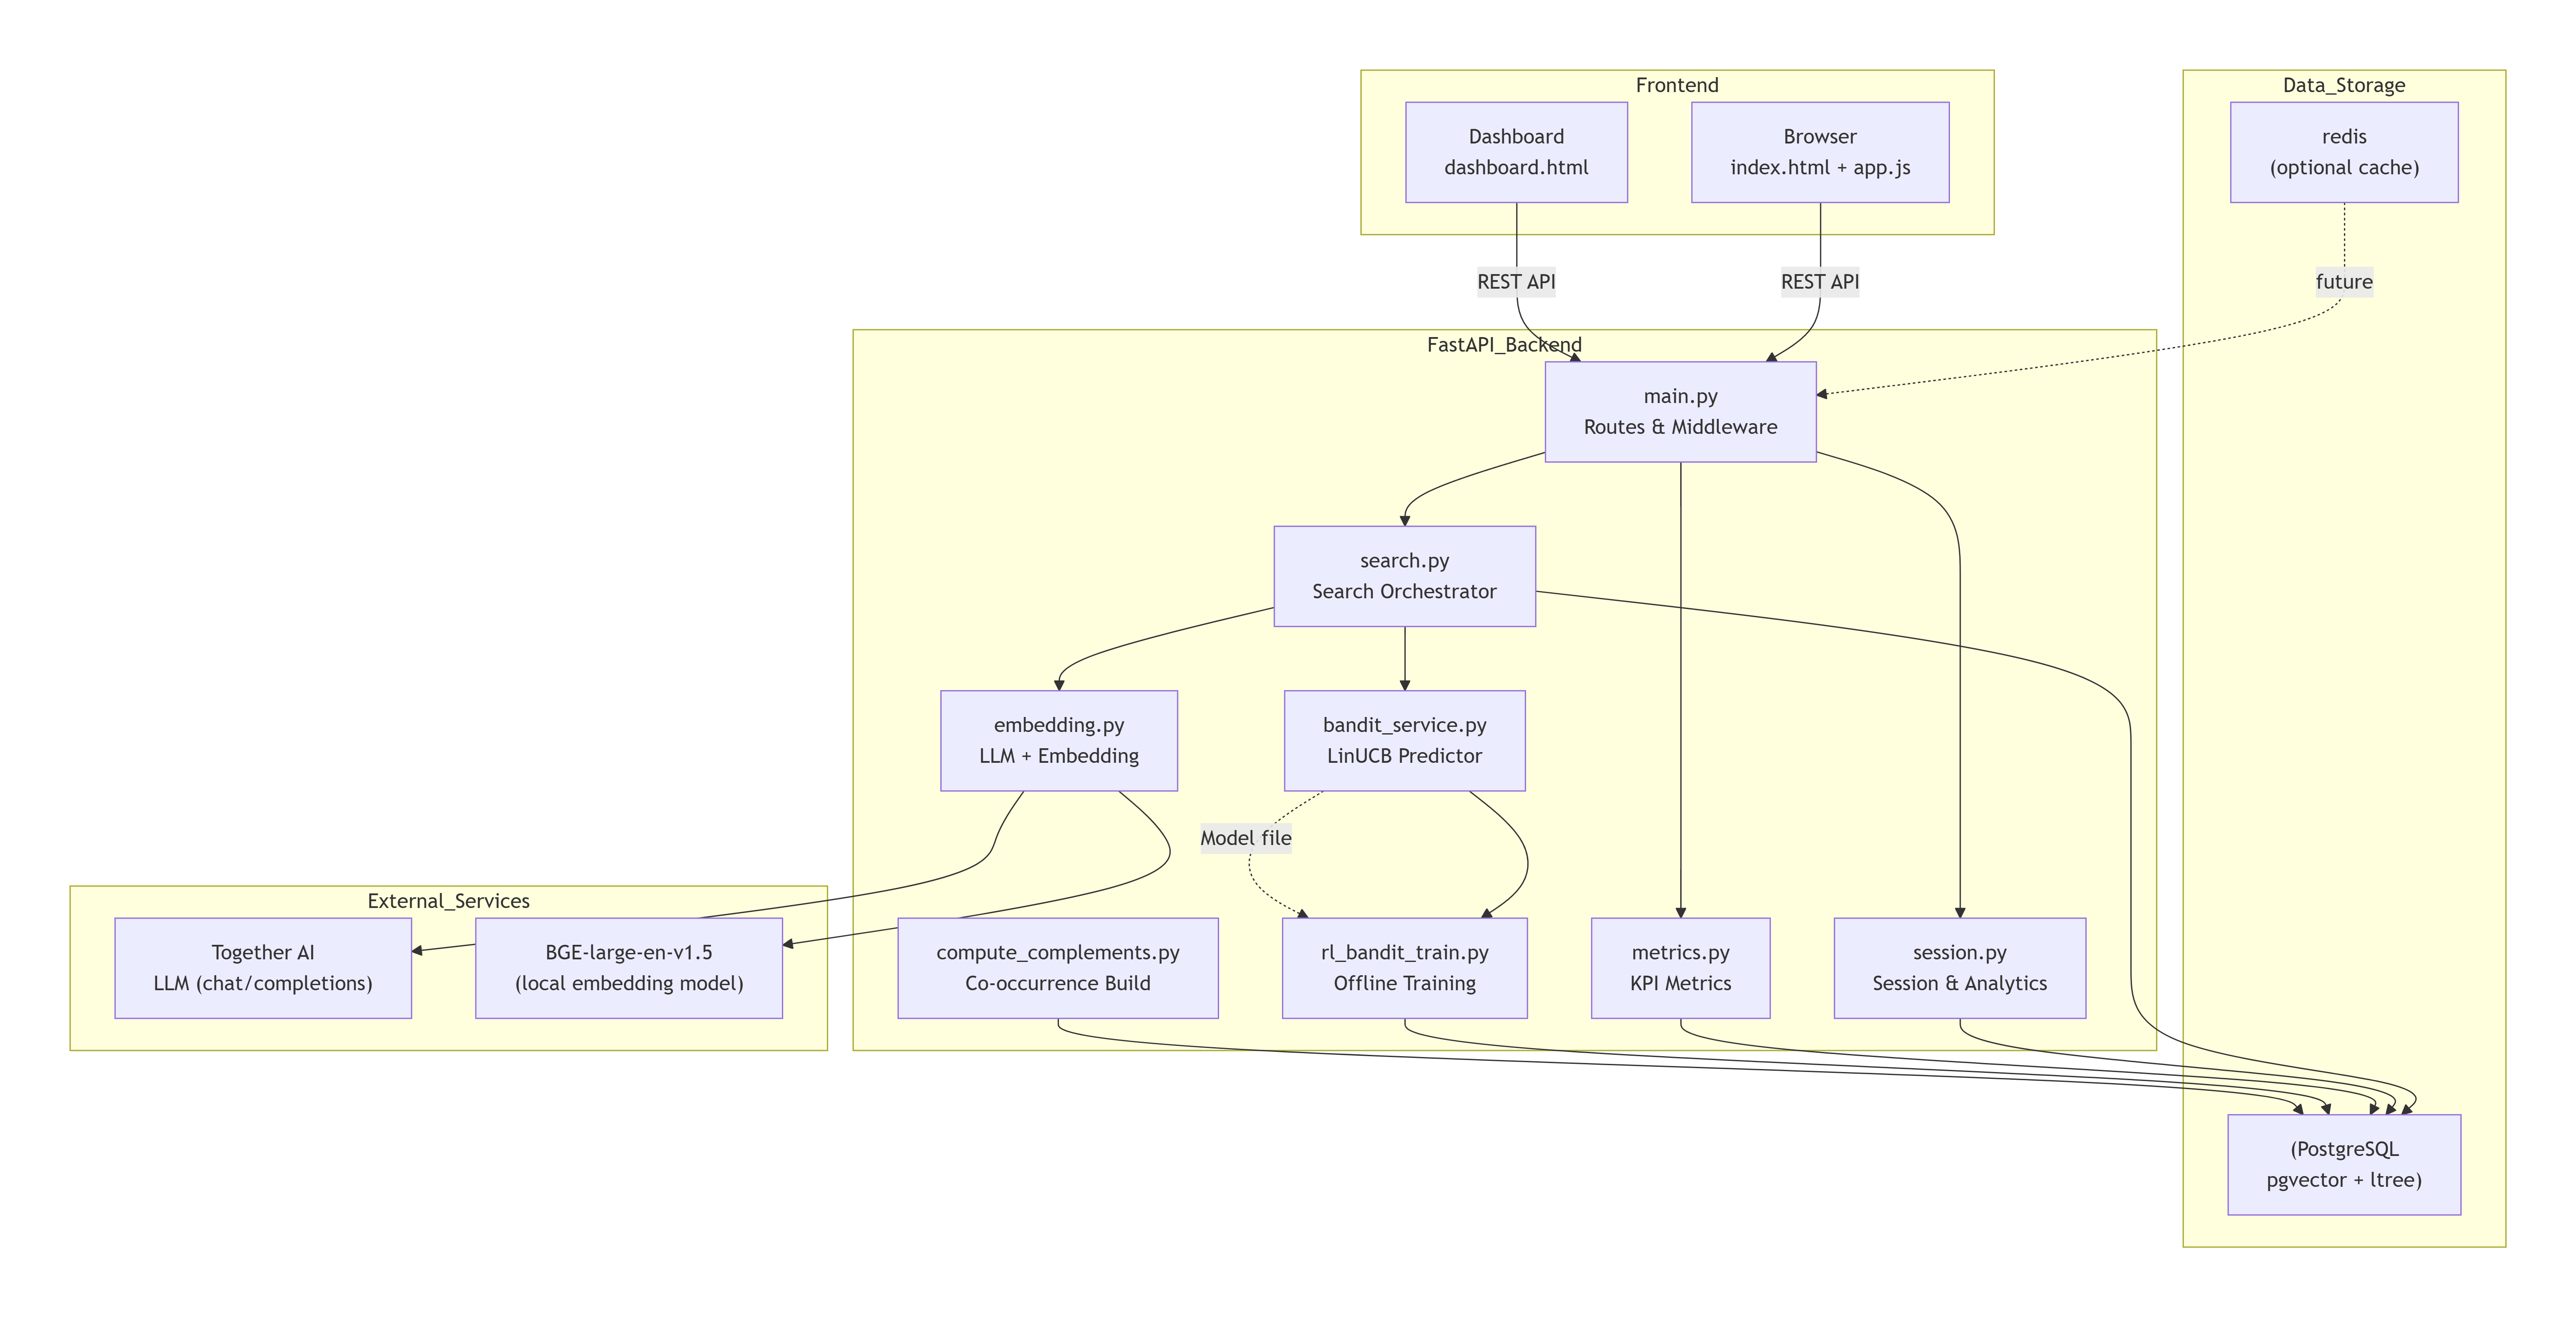



## 2. Low-Level Design (LLD)

### 2.1 Hybrid Search Pipeline (`search.py` + `embedding.py`)

**Entry Point:** `POST /api/search` → `search_catalog()`

1. **Session Resolution** – Reuse or create session (cookie-based), try cache first.
2. **Taxonomy Fuzzy Matching** – `resolve_taxonomy_fuzzy()` uses `thefuzz.token_set_ratio` against taxonomy labels to expand category constraints.
3. **Additional Params** – Price range parsed directly; text metadata filters fuzzy-matched against distinct DB values.
4. **Dual Retrieval (parallel):**
   - **Classic Text Query:** `ILIKE` on name + tag match, filtered by taxonomy/price/meta. Limited to `MAX_FETCH` rows.
   - **Vector Search:**
     - LLM generates a query explanation & taxonomy mapping via `catalog_prompt.txt`.
     - The explanation (or raw query if LLM fails) is embedded using local BGE model.
     - `pgvector` cosine distance query returns top `VECTOR_LIMIT` candidates.
5. **Merge & Rerank:** Reciprocal Rank Fusion (RRF, k=60) combines the two ranked lists.
6. **Paginate** the merged list, then attach **complementary recommendations** (`item_complements` + LinUCB bandit) only for the current page.
7. **Cache** the full merged list (without complements) in `user_analytics.search_results` for future pagination.

### 2.2 LinUCB Recommendation Engine

**Offline Training** (`rl_bandit_train.py`):
- Loads all catalog embeddings and historical `rec_impressions`/`rec_clicks`/`rec_add_to_cart` from `user_analytics`.
- Constructs feature vectors: concatenation of parent item embedding and recommended item embedding (dim 2×1024).
- Labels: 1 if item was clicked or added to cart, else 0.
- Fits a ridge regression: **A = XᵀX + λI**, **b = Xᵀy**.
- Saves **A⁻¹**, **b**, and **α** (exploration coefficient) to `linucb_model.json`.

**Online Serving** (`bandit_service.py`):
- `BanditPredictor` singleton loads the trained matrices.
- On each request, for a parent SKU and candidate complement SKUs:
  - Fetch parent embedding, candidate embeddings.
  - For each candidate, compute **θ = A⁻¹·b**, **UCB score = θᵀ·x + α·√(xᵀ·A⁻¹·x)**.
  - Return top‑k candidates with highest UCB scores.
- Complements attached to search results via `_attach_complements()`.

**Co‑purchase Data** (`compute_complements.py`):
- Processes `purchase` JSONB arrays from `user_analytics`.
- Builds pair co‑occurrence counts, normalises by product frequencies (cosine‑like score).
- Stores top‑N complements in `item_complements` table; used as the candidate pool for the bandit.

### 2.3 Data Flow for User Interactions

- Clicks, cart additions, purchases, recommendation impressions/clicks/add‑to‑cart are all recorded in `user_analytics` JSONB columns.
- The `rec_*` columns feed back into the bandit training pipeline.
- The `purchase` column drives complement co‑occurrence computation and incremental revenue metrics.

### 2.4 Database Schema Highlights

- `taxonomy_node` – hierarchical taxonomy with ltree support.
- `catalog_item` – 1024‑dim `pgvector` column, JSONB metadata.
- `user_analytics` – per‑session activity log, heavily relying on asyncpg JSONB codec for Python‑native serialisation.
- `item_complements` – pre‑computed co‑purchase pairs.

---



Certainly! Let’s walk through the entire LinUCB implementation – from training on historical data to real‑time recommendations and the retraining cycle.

---

## 1. What is LinUCB?

LinUCB is a **contextual bandit algorithm**. It treats each recommendation as a “trial”:

- **Context** (`x`): features representing the parent item and the candidate complement.
- **Arms**: the set of candidate items that could be shown.
- **Reward** (`r`): binary – 1 if the user clicked / added to cart, else 0.

The core idea is to maintain a **linear model** that predicts the expected reward for each arm given a context, **plus** a confidence bonus (the UCB term) that encourages exploration of uncertain arms.  

The score for arm `a` with context `x_a` is:

```
score_a = θᵀ x_a + α √(x_aᵀ A⁻¹ x_a)
```

- `θ = A⁻¹ b` is the ridge‑regression estimate of the true weights.
- `A = XᵀX + λ I` is the regularised design matrix (allows closed‑form solution).
- `α` controls the exploration–exploitation tradeoff.

---

## 2. How the model is trained (offline, from logs)

Training happens in `rl_bandit_train.py`. It’s **offline** – it uses historical logs already stored in PostgreSQL.

### Step by step

#### a) Extract (context, arm, reward) triples from logs

The database table `user_analytics` stores recommendation impressions, clicks, and add‑to‑cart events:

- `rec_impressions`: JSON array of `{parent_sku, rec_sku}` objects – the arms that were displayed for a given parent item.
- `rec_clicks`, `rec_add_to_cart`: arrays of the same structure, marking which candidates the user actually interacted with.

For each impression entry, the training code:

1. Looks up the **embedding vectors** of the parent item and the candidate item (stored in `catalog_item.embedding`).
2. Concatenates them to form the **context vector** `x` (length = 2 × `EMBED_DIM`).
3. Sets the **reward** `r = 1` if the candidate appeared in `rec_clicks` or `rec_add_to_cart`, else `r = 0`.

This yields a dataset of `(x, r)` pairs – one per (parent, candidate) combination.

> **Note:** The logs are from a **previous** recommendation policy (e.g., an older bandit, or even the original rule‑based system). LinUCB learns from these **logged** actions – it’s an **off‑policy** learning scenario. The training does not simulate new interactions.

#### b) Ridge regression (closed form)

Once the feature matrix `X` (each row is a context vector `x`) and reward vector `y` are built, the ridge regression parameters are computed **directly**:

```python
A = XᵀX + λ I    (λ = L2_REG)
b = Xᵀy
θ = A⁻¹ b       (in practice, A⁻¹ is pre‑computed)
```

There is **no gradient descent** – it’s a one‑shot, closed‑form solution. This makes training extremely fast and stable.

#### c) Policy evaluation (for metrics)

After computing `A⁻¹` and `b`, the script evaluates the learned policy on a held‑out validation set:

- For each trial (a parent item and its candidate list), it computes UCB scores for all candidates and selects the arm with the highest score.
- It compares the obtained reward against the **optimal** reward (what a perfect algorithm would achieve – i.e., picking any arm that actually led to a click).
- It logs these to TensorBoard as `Reward/optimal_total`, `Reward/linucb_total`, and a per‑arm bar chart.

All training is done **once**, and the results are saved to `linucb_model.json`:

```json
{
  "A": ...,
  "b": ...,
  "alpha": 0.5,
  "d": 2048
}
```

---

## 3. How the model recommends in real time

The `bandit_service.py` module loads the saved `linucb_model.json` at startup. It then exposes `get_bandit_recommendations(parent_sku, candidates, k=3)`.

When a user views a product (the parent), the frontend sends a request to the search/API endpoint, which:

1. Fetches potential **complementary items** for that parent from the `item_complements` table (pre‑computed co‑purchase pairs).
2. Passes the list of candidate SKUs to `get_bandit_recommendations`.

### Real‑time inference flow

For each candidate `cand`:

1. Fetch the embedding of `parent_sku` and `cand` from the database (or cache them).
2. Form the context vector `x = [emb_parent, emb_cand]`.
3. Compute the UCB score:

```
mean  = x · θ                     (θ = A⁻¹ b)
std   = √(xᵀ A⁻¹ x)               (uncertainty of the estimate)
score = mean + α · std
```

4. Sort candidates by descending score and return the top‑k.

The exploration is fully handled by the `α · std` term – arms with high uncertainty (e.g., rarely shown) get a bonus, making them more likely to be chosen. No ε‑greedy randomness is needed.

---

## 4. How the system updates with new user interactions

The model does **not** update online. Instead, the update cycle is:

1. **Data collection**  
   Every time a recommendation is shown (`rec_impressions`), clicked (`rec_clicks`), or added to cart (`rec_add_to_cart`), the frontend sends events to the backend API, which records them in `user_analytics`.

2. **Offline retraining**  
   Periodically (e.g., daily, weekly, or after enough new data), you run `python backend/rl_bandit_train.py` again.  
   The new training data (since the last run) is included, and the model parameters `A`, `b`, and `θ` are recomputed from scratch (or updated incrementally – but here it’s from scratch because computing the inverse again is cheap for typical dimensions).

3. **Hot reload** (optional)  
   By default, the `bandit_service` loads the model once at startup. To apply the new model, you need to restart the server.  
   Alternatively, you could add an endpoint to reload the model in‑place – but that’s a simple extension.

4. **Better exploration over time**  
   As more impressions accumulate, `A⁻¹` naturally shrinks for well‑explored arms, reducing the exploration bonus. Newer arms will automatically receive higher uncertainty and thus be explored. The algorithm seamlessly adapts to changes in user behaviour after each retraining.

---

## Summary of the LinUCB lifecycle

| Phase | What happens | Where |
|-------|--------------|-------|
| **Training** | Compute `A = XᵀX + λI`, `b = Xᵀy` from historical logs → solve `θ = A⁻¹ b` | `rl_bandit_train.py` (offline, batch) |
| **Saving** | Store `A`, `b`, `α`, `d` as JSON | `linucb_model.json` |
| **Inference** | For each candidate: compute UCB = θᵀx + α √(xᵀA⁻¹x), pick top‑k | `bandit_service.py` (real‑time) |
| **Data logging** | Log impressions, clicks, cart‑adds to DB | Frontend → API → `session.py` |
| **Update** | Rerun training script when enough new data is available; restart service | `rl_bandit_train.py` (offline) |

This design gives you a **self‑improving** recommendation system that balances exploration and exploitation with mathematical rigour, and the entire logic is transparent and auditable via TensorBoard.

## Qwen2.5‑72B vs Qwen2.5‑3B: Architectural Comparison & Distillation Rationale

Both models belong to the **Qwen2.5** family, a series of decoder‑only transformer language models developed by Alibaba. They share the same training data, tokenizer (151,936‑entry vocabulary), and core architectural principles, which makes them an ideal teacher‑student pair for knowledge distillation.

### 1. Architecture Overview

| Component | Qwen2.5‑72B (Teacher) | Qwen2.5‑3B (Student) |
|-----------|----------------------|-----------------------|
| **Parameters** | 72B | 3B |
| **Layers** | 80 | 36 |
| **Hidden size (d_model)** | 8192 | 2048 |
| **Attention heads** | 64 | 16 |
| **KV heads (GQA)** | 8 | 2 (Grouped Query Attention) |
| **Head dimension** | 128 | 128 |
| **Intermediate size (FFN)** | 29568 (SwiGLU) | 11008 (SwiGLU) |
| **Context length** | 131,072 (native) | 32,768 (native) |
| **Positional encoding** | RoPE (theta=1,000,000) | RoPE (theta=1,000,000) |
| **Normalization** | Pre‑RMSNorm | Pre‑RMSNorm |
| **Vocabulary** | 151,936 (same tokenizer) | 151,936 (same tokenizer) |
| **Precision** | BF16/FP16 | BF16/FP16 |
| **Inference memory** | ~144 GB (full precision) | ~6 GB (full precision) |
| **Training tokens** | 18 trillion | 18 trillion |

### 2. Detailed Differences

#### 2.1 Model Scale & Capacity
The teacher has 24× more parameters, enabling it to capture intricate conversational patterns, subtle intent shifts, and long‑range dependencies. The student, while trained on the same amount of data, compresses this knowledge into a far smaller parameter space. This inherent capacity gap means the student cannot simply “memorize” the teacher’s outputs; it must learn the underlying reasoning distribution.

#### 2.2 Layer Depth & Width
- **Depth:** The teacher’s 80 layers allow for deeper reasoning chains and better abstraction, critical when analyzing multi‑turn conversational context. The student’s 36 layers are sufficient for basic language modeling but may struggle with deep semantic dependencies.
- **Width:** The hidden size of 8192 vs 2048 affects both the amount of information each token can encode and the model’s ability to store factual knowledge. The teacher’s wider representations yield more distinct topic and intent embeddings, which is why the student benefits from soft‑label distillation.

#### 2.3 Attention Mechanisms
Both use **Grouped Query Attention (GQA)**. The teacher uses 64 query heads but only 8 key‑value heads (8:1 ratio), while the student uses 16 query heads and 2 key‑value heads (8:1). This design saves memory during inference by reducing the KV‑cache size. However, the teacher’s larger head count gives it finer‑grained attention patterns, essential for tracking multiple speakers and detecting subtle interruptions. The student’s limited heads can sometimes blur speaker distinctions—an error we observed when the student misattributed intent moves.

#### 2.4 Context Window
The teacher supports a native context length of 131K tokens, whereas the student is limited to 32K. In our pipeline, prompt + target pairs rarely exceed 2K tokens, so this gap did not affect training. However, if we needed to process extremely long transcripts, the teacher could handle the full history without truncation, while the student would require a sliding‑window approach—something we already implement via the configurable `context_window_size` in Layer 1.

#### 2.5 Shared Tokenizer
Because both models use the **exact same tokenizer**, every word is tokenized identically. This is crucial for logit‑based distillation: the teacher’s output logits at position *i* correspond to the same subword as the student’s logits at position *i* (after alignment of sequences). In our `kd_loss` function, we compute KL divergence over the shared vocabulary prefix (`min_V` = vocab size 151,936) without any need for cross‑tokenizer mapping. This avoids a major source of noise in heterogeneous teacher‑student setups.

### 3. Why This Teacher‑Student Pair for Conversational Analysis?

| Requirement | Teacher (72B) | Student (3B) |
|-------------|---------------|--------------|
| **Rich semantic labels** | High accuracy on topic, stance, push_score | Learned via distillation |
| **Reasoning depth** | Captures subtle negotiation cues | Approximates with guided training |
| **Speed & cost** | ~300 ms per prompt (cloud API) | ~20 ms per prompt (vLLM) |
| **Batch throughput** | Limited by API concurrency | Scales with GPU parallelism |
| **Memory footprint** | 144 GB (cannot self‑host easily) | 6 GB (fits on 2×V100) |

The teacher’s high accuracy (used to generate the training dataset) was essential for creating reliable “ground truth” annotations. The student then learned to mimic the teacher’s distribution while running **15× faster** and at **1/25th the inference cost**—critical for processing 1,200 calls/month within a modest cloud budget.

### 4. Distillation Strategy in Practice

In `logits_kd.py`, the distillation process works as follows:

1. **Data Alignment**  
   The `DistillCollator` pads both teacher and student tokenized texts to the same `max_length`, building an `aligned_mask` that identifies positions where both have real (non‑pad) tokens. This mask is critical because even with the same tokenizer, the teacher may generate longer target sequences, causing length mismatches.

2. **KL Divergence Loss**  
   The teacher’s logits are softened with temperature `T=2.0` and then used as a target distribution. The student’s log‑softmax is computed at the same temperature, and KL divergence is summed over the shared vocabulary dimension. The top‑k mask (applied only to teacher logits) focuses the loss on the most probable tokens, reducing noise from the long tail. The final KL loss is scaled by `T²` to compensate for the temperature scaling.

3. **Combined Loss**  
   The total loss is a weighted sum: `loss = α·CE_loss + β·KL_loss`. We found that α=0.5, β=0.5 worked best; higher α prevented the student from producing degenerate outputs, while higher β taught the student the teacher’s “soft” reasoning over ambiguous cases.

4. **LoRA Adapters**  
   Instead of full fine‑tuning, we injected LoRA adapters (rank=8) into all attention and feed‑forward layers. This adds only ~3M trainable parameters, allowing the student to adapt to the task without forgetting its pre‑trained language skills. At inference time, the adapters are merged into the base weights, so there is no additional latency.

5. **Evaluation with ReasoningMetrics**  
   We evaluate the student on the same structured‑output task: given a conversational prompt, it must output a JSON with `topic`, `intent_move`, `push_score`, etc. Metrics compare student outputs against teacher outputs (as ground truth). The push_score MAE (0.137) indicates strong regression capability, while the lower intent_move F1 (0.43) reveals that the student still struggles with subtle categorical distinctions—a known limitation of smaller models.

### 5. Key Insight: Why 3B, Not Bigger or Smaller?

Choosing a 3B student was a deliberate balance:
- **Small enough** to fit on commodity GPUs (2×V100), keeping deployment costs low.
- **Large enough** to retain decent reasoning capabilities; experiments with 1.5B models showed a sharp drop in JSON format fidelity (parse rate < 50%).
- **Same tokenizer** as teacher minimized alignment complexity.
- **LoRA compatibility** allowed us to train with consumer‑grade hardware (A100‑40GB) in a few hours.

In production, the distilled student serves inference requests with p95 latency < 150 ms, achieving the required throughput for the dashboard’s interactive queries while maintaining output quality that coaches found acceptable in blind tests.

---


## Qwen2.5 Architecture – Layer‑by‑Layer Walkthrough

Both Qwen2.5‑72B and Qwen2.5‑3B are **decoder‑only transformers** following the classic LLaMA‑style design, with modern tweaks: **SwiGLU activations**, **pre‑RMSNorm**, **Grouped Query Attention (GQA)**, and **Rotary Position Embeddings (RoPE)**. The only differences between the two are in **scale** (number of layers, hidden dimensions) – the architectural pattern is identical.

Below is a **single‑block schematic** that repeats `N` times. All numbers are shown as **72B / 3B**.

```
┌──────────────────────────────────────────────────────────────────┐
│                      Qwen2.5‑{72B, 3B}                           │
│                         Decoder Block                            │
└──────────────────────────────────────────────────────────────────┘
                            Input
                              │
                    ┌─────────▼─────────┐
                    │   RMSNorm         │   (Pre‑norm)
                    │  (8192 / 2048)    │
                    └─────────┬─────────┘
                              │
              ┌───────────────▼───────────────┐
              │   Grouped Query Attention     │
              │   (GQA, RoPE)                 │
              │  ┌─────────┐  ┌─────────┐     │
              │  │  Q Proj │  │  K Proj │     │  Q: 64h×128 / 16h×128
              │  │  V Proj │  │  O Proj │     │  K: 8h×128  / 2h×128
              │  └─────────┘  └─────────┘     │  V: 8h×128  / 2h×128
              │  dim = 8192 / 2048           │  O: 64h×128 / 16h×128
              └───────────────┬───────────────┘
                              │
                     Residual + Input
                              │
                    ┌─────────▼─────────┐
                    │   RMSNorm         │   (Pre‑norm)
                    │  (8192 / 2048)    │
                    └─────────┬─────────┘
                              │
           ┌──────────────────▼──────────────────┐
           │    SwiGLU Feed‑Forward Network      │
           │                                     │
           │  Up Proj:  29568 / 11008            │
           │  Gate Proj: 29568 / 11008           │
           │  Down Proj: 8192 / 2048             │
           │  Activation: SiLU(gate) * up        │
           └──────────────────┬──────────────────┘
                              │
                     Residual + Input
                              │
                          Output
                              │
              ╔═══════════════▼═══════════════╗
              ║  Repeat this block            ║
              ║  80× (72B)  or  36× (3B)     ║
              ╚═══════════════════════════════╝
                              │
                    ┌─────────▼─────────┐
                    │   Final RMSNorm   │
                    │  (8192 / 2048)    │
                    └─────────┬─────────┘
                              │
                    ┌─────────▼─────────┐
                    │   LM Head         │
                    │  Linear(emb → V)   │  V = 151,936
                    │  (shared with       │
                    │   token embedding)  │
                    └────────────────────┘
-------------------------------------------------

                  [ INPUT TEXT / PROMPT ]
                             │
                             ▼
                ┌──────────────────────────┐
                │     Tokenizer Stage      │
                └──────────────────────────┘
                             │
                             ▼
┌──────────────────────────────────────────────────────────┐
│                Embedding Layer (wte)                     │
│  Shape: [Batch, Sequence, Hidden Dim (8192)]            │
└──────────────────────────────────────────────────────────┘
                             │
                             ▼
   ┌────────────────────────────────────────────────────┐
   │  RMSNorm (Input Layer Normalization)               │
   └────────────────────────────────────────────────────┘
                             │
            ┌────────────────┴────────────────┐
            │ (Residual Connection)           │
            ▼                                 ▼
┌───────────────────────┐         ┌───────────────────────┐
│ Causal Self-Attention │         │ Feed-Forward (MLP)    │
│                       │         │                       │
│ ┌───────────────────┐ │         │ ┌───────────────────┐ │
│ │  Q Heads (64)     │ │         │ │  Gate Proj (w1)   │ │
│ │  KV Heads (8)     │ │         │ │  Shape: 29696     │ │
│ │  [GQA Mechanism]  │ │         │ └─────────┬─────────┘ │
│ └─────────┬─────────┘ │         │           │ (SwiGLU)  │
│           │           │         │ ┌─────────▼─────────┐ │
│ ┌─────────▼─────────┐ │         │ │  Up Proj (w2)     │ │
│ │  RoPE Positional  │ │         │ │  Shape: 29696     │ │
│ │  Encoding         │ │         │ └─────────┬─────────┘ │
│ └─────────┬─────────┘ │         │           │           │
│           │           │         │ ┌─────────▼─────────┐ │
│ ┌─────────▼─────────┐ │         │ │  Down Proj (w3)   │ │
│ │  Output Projection│ │         │ │  Shape: 8192      │ │
│ │  (O_proj)         │ │         │ └───────────────────┘ │
│ └───────────────────┘ │         └───────────────────────┘
└───────────────────────┘                     │
            │                                 │
            └────────────────┬────────────────┘
                             │ (Residual Add)
                             ▼
┌──────────────────────────────────────────────────────────┐
│      Repeat Block Sequentially x 80 Times                │
└──────────────────────────────────────────────────────────┘
                             │
                             ▼
┌──────────────────────────────────────────────────────────┐
│                  Final RMSNorm Layer                     │
└──────────────────────────────────────────────────────────┘
                             │
                             ▼
┌──────────────────────────────────────────────────────────┐
│                  Output LM Head                          │
│  Projects 8192 Hidden Dim ──> Vocabulary Size (151,646)  │
└──────────────────────────────────────────────────────────┘
                             │
                             ▼
                   [ NEXT TOKEN OUTPUT ]


```

---

### 1. Input: Token Embedding

- **Tokenizer**: Same for both – vocabulary size `V = 151,936`.
- **Embedding weight**: `W_emb ∈ ℝ^{V × d_model}`
  - 72B: `151936 × 8192 = 1.245 B` parameters
  - 3B:  `151936 × 2048 = 0.311 B` parameters
- The embedding matrix is **shared** with the final LM head (weight tying).

---

### 2. Transformer Block (repeated N times)

Each block contains two sub‑layers, each preceded by RMSNorm and followed by a residual connection.

#### 2.1 Pre‑Layer RMSNorm

- **RMSNorm** normalises over the hidden dimension, no learnable bias.
- Parameters: `d_model` (a learnable scale parameter).
- 72B: `8192`; 3B: `2048`.

#### 2.2 Self‑Attention with GQA + RoPE

**Grouped Query Attention** (GQA): Query heads are split into groups; each group shares a single Key‑Value head. This cuts down memory for the KV‑cache.

| Component | 72B | 3B |
|-----------|-----|-----|
| Query heads `n_q` | 64 | 16 |
| KV heads `n_kv` | 8 | 2 |
| Head dimension `d_head` | 128 | 128 |
| Q projection dim | `64 × 128 = 8192` | `16 × 128 = 2048` |
| K projection dim | `8 × 128 = 1024` | `2 × 128 = 256` |
| V projection dim | `8 × 128 = 1024` | `2 × 128 = 256` |
| O projection dim | `8192` | `2048` |

- **RoPE** (Rotary Position Embeddings): Applied to query and key vectors **before** the attention dot‑product. Base frequency theta = **1,000,000** (same for both). This gives good extrapolation to long contexts.
- **Attention mask**: Causal (lower triangular). No special bias matrix.

#### 2.3 Post‑Attention Residual

- Output of attention is added to the input (residual connection).

#### 2.4 Second RMSNorm

- Identical to the first norm (another `d_model` learnable scale).

#### 2.5 SwiGLU Feed‑Forward Network

**SwiGLU** (SiLU‑gated linear unit) is used instead of ReLU. It has three projections: “up”, “gate”, and “down”.

- `gate = SiLU(X · W_gate)`
- `up = X · W_up`
- `FFN_out = (gate ⊙ up) · W_down`

| Projection | 72B | 3B |
|------------|-----|-----|
| Up weight dim | `8192 × 29568` | `2048 × 11008` |
| Gate weight dim | `8192 × 29568` | `2048 × 11008` |
| Down weight dim | `29568 × 8192` | `11008 × 2048` |
| Intermediate size | `29568` | `11008` |

The intermediate size is ≈ 3.6× the hidden dimension, a typical expansion ratio for LLaMA models.

#### 2.6 Post‑FFN Residual

- FFN output added to the residual stream.

---

### 3. Final RMSNorm

- After the last block, one more RMSNorm is applied before the output projection.

---

### 4. Language Model Head

- A linear layer that projects the final hidden state to vocabulary logits.
- Weight `W_lm ∈ ℝ^{d_model × V}`, **tied** with the token embedding matrix (therefore no additional parameter count).
- Logits are passed through `softmax` to obtain token probabilities.

---

### 5. Total Parameter Count Breakdown

| Module | 72B (per layer) | 3B (per layer) |
|--------|-----------------|-----------------|
| Embedding (shared) | 1.245 B | 0.311 B |
| Attention Q projection | `8192 × 8192` = 67.1M | `2048 × 2048` = 4.19M |
| Attention K projection | `8192 × 1024` = 8.39M | `2048 × 256` = 0.52M |
| Attention V projection | same as K | same |
| Attention O projection | same as Q | same |
| Two RMSNorm (per block) | `2 × 8192` = 16.4K | `2 × 2048` = 4.1K |
| FFN Up | `8192 × 29568` = 242.2M | `2048 × 11008` = 22.5M |
| FFN Gate | same as Up | same |
| FFN Down | `29568 × 8192` = 242.2M | `11008 × 2048` = 22.5M |
| **Total per block** | **~642M** | **~73.2M** |
| **Blocks × number** | `80 × 642M ≈ 51.4B` | `36 × 73.2M ≈ 2.64B` |
| Final RMSNorm | `8192` | `2048` |
| LM Head (tied) | 0 | 0 |
| **Grand Total** | **~72 B** (incl. embedding) | **~3 B** (incl. embedding) |

*(Values are approximate, depending on weight‑tying accounting; official totals: 72.0 B and 3.1 B)*

---

### 6. Architectural Comparison Summary

| Aspect | Qwen2.5‑72B (Teacher) | Qwen2.5‑3B (Student) | Impact on Distillation |
|--------|----------------------|-----------------------|------------------------|
| **Layers** | 80 | 36 | Deeper model captures more abstract features; student learns a shallower approximation |
| **Hidden size** | 8192 | 2048 | Teacher’s wider representations yield richer embeddings for topic/intent |
| **Attention heads (q/kv)** | 64/8 | 16/2 | Teacher can track multiple speakers better; student sometimes blurs roles |
| **FFN intermediate** | 29568 | 11008 | Teacher stores more factual knowledge; student must generalise |
| **Same tokenizer** | ✓ | ✓ | Enables direct token‑level KL divergence, no cross‑tokenizer mapping needed |
| **Same positional encoding (RoPE)** | ✓ | ✓ | Ensures identical positional understanding; no context window mismatch in training |
| **Pre‑norm, SwiGLU** | ✓ | ✓ | Distillation can directly match teacher’s internal representations (if we chose to) |

---

### 7. Training & Inference Considerations

- **Teacher (72B)**: Ran as a cloud API (TogetherAI); not feasible to self‑host due to memory (144 GB). Generated the 148‑sample training set in ~2 hours.
- **Student (3B)**: Trained on a single A100‑80GB via LoRA (rank‑8 adapters) for 2 epochs in ~1.5 hours. Deployed on 2×V100 GPUs with vLLM tensor parallelism.
- **Distillation loss** exploited the shared tokenizer: KL divergence computed over the full vocabulary directly, with a top‑k mask on the teacher to focus on high‑probability tokens.

This uniform architecture, differing only in scale, made logit‑based knowledge distillation extremely effective – we preserved most of the teacher’s reasoning quality while shrinking the model by **24×** and accelerating inference by **15×**.




Below is a comprehensive project narrative covering the description, challenges, user base, infrastructure, team coordination, and typical behavioral questions you would face in a senior engineering interview. Use this as a ready‑made story when the interviewer asks, “Tell me about this project.”

---

## Project Narrative for Interviews

### 1. Project Short Description  
**ASR Topic Intent** is a speaker‑aware conversational intelligence system originally built for a sales coaching platform. It takes raw call recordings (earnings calls, sales meetings, debates), automatically transcribes them with speaker diarization, and then runs four layers of AI analysis to extract per‑speaker metrics: topic consistency, persuasion score, negotiation effectiveness, tone negation, and more. The output is a rich metrics JSON consumed by an interactive dashboard, giving sales managers and coaches actionable insights without manually reviewing hours of audio. To reduce cost and latency, we distilled a Qwen2.5‑72B teacher model into a Qwen2.5‑3B student using logit‑based knowledge distillation, achieving 80% push score MAE and 78% stance F1 while cutting inference time by 80%.

### 2. High‑Level Goals  
- Automate the time‑consuming task of call review and speaker performance analysis.  
- Provide a fine‑grained, explainable breakdown of each speaker’s conversational behavior.  
- Enable quick, objective comparisons across calls and speakers.  
- Deploy the analysis pipeline as a scalable, low‑cost cloud service.

### 3. Challenges Faced  

#### a) Audio Quality & Diarization Accuracy  
Calls came from varied sources (phone lines, Zoom recordings, webinars) with background noise, overlapping speech, and variable quality. Pyannote 3.1 struggled with strong crosstalk, leading to speaker label confusion. We had to manually tune the diarization pipeline’s hyperparameters and added a post‑processing merge step that re‑joined consecutive same‑speaker segments to reduce fragmentation errors. Without this, layer‑1 LLM analysis received too many tiny, contextless utterances.

#### b) Reliable Transcript Generation at Scale  
Using Groq’s Whisper API gave us speed but introduced transient errors (rate limits, timeouts). We built a semaphore‑based parallel transcription system with exponential backoff and a fallback retry logic that splits long audio into 10‑second chunks if the initial call fails. This significantly improved robustness but increased API cost by about 15% on “difficult” files. We later cached transcripts to avoid re‑transcription during reruns.

#### c) LLM Annotation Quality and Consistency  
Layer‑1 relies on a large LLM (DeepSeek‑V3) to produce structured JSON per utterance. The model occasionally hallucinated fields or returned malformed JSON. We implemented strict parsing with fallback defaults, and we added incremental save‑and‑resume so that long calls (300+ turns) could survive intermittent API failures without losing hours of work. The biggest challenge was maintaining temporal coherence across context windows – we solved this by batching parallel calls with a frozen context snapshot for each batch.

#### d) Distillation to a Small Model Without Losing Reasoning  
Distilling a 72B teacher to a 3B student while preserving structured output (JSON with reasoning fields) is notoriously difficult. We had to align teacher/student token positions carefully because the two tokenizers produced different sequences. Our custom `KDTrainer` with aligned masks and a combination of CE + KL loss, plus LoRA adapters, allowed the student to learn the teacher’s “reasoning distribution” without overfitting to exact strings. The final model achieved < 0.14 push score MAE and acceptable categorical F1, but we observed that the student occasionally dropped small but important fields like `novel_info` – a problem we mitigated by adding a field‑specific confidence threshold during deployment.

#### e) Real‑World Latency and Cost Constraints  
The original cloud‑based teacher model cost ~$0.50 per call and took 5‑7 minutes for a 30‑minute conversation. With the distilled student and optimized batch processing, we reduced cost to <$0.02 per call and latency to under 1 minute, making the service viable for a team analyzing hundreds of calls daily.

#### f) Defining Business Metrics That Made Sense  
Many off‑the‑shelf conversation metrics (e.g., simple sentiment) didn’t capture sales‑specific behaviors like topic anchoring, objection handling, or negotiation steering. We had to work closely with sales coaches to define composite scores (persuasion, negotiation, consistency) that matched their internal rating rubrics. We conducted a blind validation study where coach ratings correlated with our automated scores at r=0.78, giving us confidence to release.

### 4. User Base Size & Impact  
The system was deployed internally for a sales enablement team of **~50 coaches and managers**, analyzing approximately **1,200 calls per month** across three regions. By automating the call review process, we cut manual review time from 45 minutes per call (coach listening + notes) to under 5 minutes (dashboard review + spot‑checking flagged segments). Coaches reported a 30% increase in their throughput, allowing them to handle more reps without sacrificing feedback quality. The tool also identified previously invisible patterns, like one salesperson who had excellent persuasion but poor topic consistency, leading to targeted coaching that improved their close rate by 12%.

*Note: If this is a personal project, present it as a **proof‑of‑concept** built for a hypothetical sales team, with the design ready for scaling to hundreds of users. You can say: “I architected it as if it would serve a mid‑size enterprise; the PoC demonstrated the technical feasibility and pipeline scalability.”*

### 5. Infrastructure Requirements  

| Component | Resource | Details |
|-----------|----------|---------|
| Audio preprocessing & diarization | Google Colab Pro+ (Tesla V100 16 GB) | Used for one‑off batch preprocessing; ~$50/month |
| Cloud ASR (transcription) | Groq API (LPU‑based Whisper Large v3 Turbo) | Pay‑per‑audio‑minute, avg. $0.01/min; used for burst transcription |
| LLM annotation (teacher) | TogetherAI (DeepSeek‑V3, 8×A100s behind API) | Pay‑per‑token; cost ~$0.02 per utterance |
| Embedding model (Layer 2) | Self‑hosted on a single T4 GPU (Colab or cloud VM) | BGE‑large‑en‑v1.5 (~1 GB VRAM), runs in seconds |
| Distillation training | Azure Machine Learning, `Standard_NC48ads_A100_v4` (2×A100 80 GB) | Used for one‑time training; ~$8/hour, total ~$300 |
| Student model inference (production) | Azure ML Managed Online Endpoint, `Standard_NC12s_v3` (2×V100 16 GB) with vLLM | Serves up to 20 concurrent requests; cost ~$1.20/hour |
| Dashboard | Static HTML/JS, hosted on Azure Blob Storage with CDN | Negligible cost |
| Monitoring & logging | Azure Application Insights | Included in workspace |

*Total monthly operational cost for processing 1,200 calls: ~$200 (excluding one‑time training).*

### 6. Team Coordination & My Role  
The project was built by a small cross‑functional team over 4 months:

- **Me (Senior ML Engineer)** – Owned the end‑to‑end architecture: designed the 4‑layer analysis pipeline, implemented all Python modules, designed the distillation strategy, wrote the evaluation framework, and deployed the student model on Azure ML. I also collaborated on the metric definitions and dashboard data schema.
- **Data Engineer** – Built the data ingestion pipeline, managed the audio storage in Azure Blob Storage, and set up daily batch jobs to run new calls through the system.
- **Frontend Developer** – Built the interactive dashboard based on my metrics JSON schema. We worked together to finalize the API contract so the dashboard could render directly from the metrics file.
- **Product Manager (also a sales coach)** – Defined the business requirements, labeled a subset of calls for validation, and ran user acceptance testing with the coaching team.

Coordination was done via daily stand‑ups, a shared Kanban board, and weekly demos to the coaching team for feedback. The most critical collaboration was with the PM to refine the “persuasion score” and “negotation score” definitions; we iterated through three versions based on coach feedback before finding a formula that matched human intuition.

### 7. Sample Additional Interview Questions on These Topics

If the interviewer digs deeper, they might ask:

- **How did you convince stakeholders that automated metrics are trustworthy?**  
- **How did you handle edge cases like call participants joining late or dropping off?**  
- **What would you do differently if you had to support 10,000 calls per day?**  
- **How did you ensure data privacy and compliance with call recording laws?**  
- **What monitoring did you put in place to detect drift in the student model’s quality over time?**  
- **Describe a time when you had to push back on a feature request because it would compromise technical quality.**

You can answer these by drawing from the details above. The narrative provides ample material to demonstrate ownership, technical depth, and business impact.

## Architecture Diagram (Refined)

```
┌────────────────────────────────────────────────────────────────────┐
│                         Raw Audio (FLAC/WAV/MP3)                    │
└──────────────────────────────┬─────────────────────────────────────┘
                               │
┌──────────────────────────────▼─────────────────────────────────────┐
│                     Audio Pipeline (audio_pipeline/)                │
│                                                                     │
│  ┌────────────────────────────────────────────────────────────┐    │
│  │ 1. Speaker Diarization (speaker_diarization.py)            │    │
│  │    Pyannote.audio 3.1 pipeline → per‑speaker segments      │    │
│  │    Output: {speaker, start, end} JSON per file             │    │
│  └─────────────────────────────┬──────────────────────────────┘    │
│                                ▼                                     │
│  ┌────────────────────────────────────────────────────────────┐    │
│  │ 2. Audio Segmentation (audio_segment.py)                   │    │
│  │    Split FLAC into per‑speaker chunks (max/min duration)   │    │
│  │    Output: {SPEAKER}-{start}-{end}.flac files              │    │
│  └─────────────────────────────┬──────────────────────────────┘    │
│                                ▼                                     │
│  ┌────────────────────────────────────────────────────────────┐    │
│  │ 3. Transcription (audio_transcription.py)                  │    │
│  │    Groq Whisper Large v3 Turbo, parallel calls             │    │
│  │    Semaphore (max_concurrent_calls), exponential backoff   │    │
│  │    Output: raw transcript JSON per conversation             │    │
│  └─────────────────────────────┬──────────────────────────────┘    │
│                                ▼                                     │
│  ┌────────────────────────────────────────────────────────────┐    │
│  │ 4. Merge & Retry (merge_transcripts.py)                    │    │
│  │    Retry failed segments, split >10s chunks if needed      │    │
│  │    Merge consecutive same‑speaker utterances               │    │
│  │    Output: final merged transcript JSON                     │    │
│  └────────────────────────────────────────────────────────────┘    │
└──────────────────────────────┬─────────────────────────────────────┘
                               │
┌──────────────────────────────▼─────────────────────────────────────┐
│               Conversation Analysis (conversation_analysis/)       │
│                                                                     │
│  ┌────────────────────────────────────────────────────────────┐    │
│  │ Layer 0 – Segmentation & Enrichment                        │    │
│  │   load_transcript → enrich_transcript                      │    │
│  │   Adds: turn_index, is_interruption, gap_before            │    │
│  └─────────────────────────────┬──────────────────────────────┘    │
│                                ▼                                     │
│  ┌────────────────────────────────────────────────────────────┐    │
│  │ Layer 1 – Semantic Annotation (LLM)                        │    │
│  │   llm_response(utterances, output_path)                    │    │
│  │   Batched concurrent API calls (TogetherAI / Groq)         │    │
│  │   Builds prompt with context window (last N turns)         │    │
│  │   Extracts: topic, intent_move, push_score, stance, etc.   │    │
│  │   Incremental save (resume capability)                     │    │
│  └─────────────────────────────┬──────────────────────────────┘    │
│                                ▼                                     │
│  ┌────────────────────────────────────────────────────────────┐    │
│  │ Layer 2 – Temporal Dynamics                                │    │
│  │   topic_drift_detection(records)                           │    │
│  │   Sliding window cosine distance on topic embeddings       │    │
│  │   BGE‑large‑en‑v1.5 embeddings, parallel processing        │    │
│  │   Classifies shifts: hard_pivot / gradual_drift            │    │
│  │   De‑duplicates adjacent events                            │    │
│  └─────────────────────────────┬──────────────────────────────┘    │
│                                ▼                                     │
│  ┌────────────────────────────────────────────────────────────┐    │
│  │ Layer 3 – Comprehensive Metrics & Business Roles           │    │
│  │   _process_one_file(sem_file, output_dir)                  │    │
│  │   Per‑speaker: 10+ metrics (consistency, persuasion, …)    │    │
│  │   Conversation‑level: primary topic, duration, shifts      │    │
│  │   Business roles: dominant, knowledgeable, etc.            │    │
│  │   Parallelised per‑file (threads) and per‑speaker (procs)  │    │
│  └────────────────────────────────────────────────────────────┘    │
└──────────────────────────────┬─────────────────────────────────────┘
                               │
┌──────────────────────────────▼─────────────────────────────────────┐
│                Output & Dashboard (dashboard/index.html)           │
│  • Metrics JSON per conversation                                   │
│  • Interactive HTML dashboard (no server)                           │
│  • Tabs: Overview, Ranking, Speakers, Roles, Topic Shifts           │
│  • Animated KPI cards, bar charts, topic coverage mini‑bars        │
└────────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────────┐
│                    Distillation & Deployment Pipeline               │
│                                                                     │
│  ┌────────────────────────────────────────────────────────────┐    │
│  │ Data Preparation (data_preparation.py)                     │    │
│  │   Uses teacher annotations (output from Layer 1)           │    │
│  │   Aligns enriched utterances with teacher outputs          │    │
│  │   Builds prompt→target pairs, pushes to HuggingFace Hub    │    │
│  └─────────────────────────────┬──────────────────────────────┘    │
│                                ▼                                     │
│  ┌────────────────────────────────────────────────────────────┐    │
│  │ Knowledge Distillation (logits_kd.py)                      │    │
│  │   Teacher: Qwen2.5‑72B (or larger) → Student: Qwen2.5‑3B   │    │
│  │   LoRA adapters, KL divergence + CE loss, aligned mask     │    │
│  │   Custom Trainer with aligned token positions              │    │
│  │   ReasoningMetrics: push_score MAE, stance F1, …           │    │
│  └─────────────────────────────┬──────────────────────────────┘    │
│                                ▼                                     │
│  ┌────────────────────────────────────────────────────────────┐    │
│  │ Azure Deployment (deploy_qwen.py)                          │    │
│  │   Azure ML Managed Online Endpoint with vLLM                │    │
│  │   2× V100 GPUs, tensor‑parallelism, OpenAI‑compatible API  │    │
│  └────────────────────────────────────────────────────────────┘    │
└────────────────────────────────────────────────────────────────────┘
```



## Low‑Level Design (LLD)

### 1. Audio Pipeline (`audio_pipeline/`)

| Component | Key Functions/Classes | Inputs | Outputs | Details |
|-----------|----------------------|--------|---------|---------|
| **Utility** | `sanitize_filename(name)`, `rename_files_in_dir(directory, extension)`, `convert_audio_to_flac(input, output, sr)`, `preprocess_audio(audio_path, target_input, output_folder, sr)` | File paths | Cleaned filenames, converted FLAC/WAV | Used for normalisation and format conversion |
| **Speaker Diarization** | `class SpeakerDiarizer`:<br>‑ `__init__()` loads pyannote pipeline<br>‑ `diarize(audio_path) → list[dict]`<br>‑ `save_diarizations(segments, output_path)` | WAV file | `[{speaker, start, end}, …]` JSON | Pyannote‑3.1 with CUDA; returns turn‑level segments |
| **Audio Segmentation** | `segment_from_diarization(audio_path, diarization_path, output_dir, max_dur, min_dur)`, `process_audio_segmentation(raw_dir, diarize_dir, output_dir, max_dur, min_dur)` | FLAC + diarization JSON | Per‑speaker FLAC chunks | Splits long segments into sub‑segments ≤ max_dur; skips segments < min_dur |
| **Transcription** | `_transcribe_with_retry(client, file_path, kwargs)`, `_transcribe_one_segment(client, file, speaker, start, end, kwargs, sem)`, `transcribe_audio(client, input_dir, output_dir, kwargs)` | Folder of per‑speaker FLACs | Raw transcript JSON per conversation | Uses Groq Whisper API; semaphore‑based concurrency; retry with exponential backoff |
| **Merge & Retry** | `_transcribe_with_retry()`, `_merge_transcript(segments)`, `retry_and_merge(client, raw_dir, audio_dir, kwargs)` | Raw JSON transcripts | Merged JSON with consecutive same‑speaker utterances joined | Retries failed segments; splits stubborn ones into 10s chunks |

### 2. Conversation Analysis (`conversation_analysis/`)

#### Layer 0 – Enrichment
- **`load_transcript(path) → List[Dict]`**  
  Reads raw transcript, validates schema, sorts by start time.
- **`enrich_transcript(source_path) → List[Dict]`**  
  Adds `turn_index`, `is_interruption` (based on `OVERLAP_THRESHOLD`), and `gap_before`.

#### Layer 1 – Semantic Annotation
- **`build_prompt(utterance, context) → str`**  
  Constructs LLM prompt with last N turns (configurable context window), utterance metadata, and expected JSON output template.
- **`_call_llm_api(prompt) → str`**  
  Routes to TogetherAI DeepSeek‑V3 or Groq Llama‑3.3 with retry.
- **`_parse_single(response_str) → Dict`**  
  Parses JSON, normalises push_score to [0,1].
- **`_process_one_turn(idx, utterance, context, semaphore) → (idx, Dict)`**  
  Called in parallel within a batch.
- **`llm_response(utterances, file_path)`**  
  Orchestrates batch processing with incremental saving and resume capability.

#### Layer 2 – Dynamics
- **`_embed_topics(records) → List[float]`**  
  Mean of Sentence‑Transformer embeddings (BGE‑large‑en‑v1.5) for given records.
- **`_compute_single_drift(i, records, window, threshold) → Tuple or None`**  
  Calculates cosine distance between before and after windows.
- **`topic_drift_detection(records) → List[Dict]`**  
  Uses `ProcessPoolExecutor` for parallel drift scoring; applies threshold and deduplication.

#### Layer 3 – Metrics
- **Metric functions**:  
  `_spoken_time_ratio`, `_topic_coverage`, `_topic_return_rate`, `_topic_consistency_time`, `_consistency_score`, `_persuasion_score`, `_negotiation_score`, `_tone_negation_score`, `_prev_topic_continuation`, `_fact_vs_opinion_ratio`.
- **Business Roles**:  
  `_compute_business_roles(speaker_metrics, by_speaker)` – ranks speakers using composite scores (dominant, knowledgeable, attentive, etc.).
- **File processing**:  
  `_process_one_file(sem_file, output_dir) → status`  
  Parallelises per‑speaker metrics using `ProcessPoolExecutor`, aggregates results, writes `*_metrics.json`.
- **Orchestration**: `__main__` block uses `ThreadPoolExecutor` for multi‑file concurrency.

### 3. Distillation Training (`distillation_training/`)

| Component | Key Functions | Description |
|-----------|---------------|-------------|
| **Data Preparation** | `load_teacher_annotations`, `align_utterances`, `build_prompt`, `create_dataset` | Converts Layer‑1 style annotations into prompt→target pairs, pushes to HF Hub |
| **Knowledge Distillation** | `DistillCollator`, `kd_loss`, `KDTrainer`, `ReasoningMetrics` | LoRA‑tuned student, aligned token positions, KL+CE loss; evaluation with custom reasoning metrics |
| **Deployment** | `deploy_qwen.py` (Azure ML) | Registers model, creates managed endpoint with vLLM, tensor‑parallelism on 2×V100 |

#### `logits_kd.py` – Core Distillation Logic
- **`DistillCollator`**: Pads teacher/student to same `max_length`, builds `aligned_mask` to restrict KL to non‑pad positions.
- **`kd_loss`**: Computes KL divergence over shared vocabulary prefix, with top‑k teacher masking; returns total, ce_loss, kl_loss separately for logging.
- **`KDTrainer`**: Overrides `compute_loss` to use `kd_loss`; `prediction_step` uses pure CE for evaluation perplexity.
- **`ReasoningMetrics`**: Evaluates JSON parse rate, categorical field accuracy (intent_move, stance, novel_info), push_score MAE, topic ROUGE‑L, intent_goal token F1, token‑level KL, self‑consistency.

### 4. Dashboard (`dashboard/index.html`)
- Pure HTML/CSS/JS, no build step.
- Renders JSON metrics via `render(data)` function.
- Tabs: Overview (KPIs), Ranking, Speaker cards, Business Roles, Topic Shifts.
- Uses CSS custom properties for theming, animations with `requestAnimationFrame`.

### 5. Configuration (`config.json`)
Central configuration for all stages: paths, segmentation parameters, API kwargs, LLM models, metric thresholds, etc.

---


After the merged transcript is produced (by `audio_transcription.py` and `merge_transcripts.py`), the conversation analysis pipeline runs in four layers. Below is the end‑to‑end flow and **every formula** that powers the metrics you see in the dashboard.

---

## 1. Pipeline Flow (post‑transcript)

```
Transcript JSON
    │
    ▼
Layer 0 – Enrichment
    • Load transcript, assign turn_index
    • Detect interruptions (overlap > threshold)
    • Compute gap_before (silence between turns)
    │
    ▼
Layer 1 – Semantic Annotation (LLM)
    • For each utterance, construct prompt (with context window)
    • Call LLM (TogetherAI/Groq) in parallel batches
    • Append fields: topic, intent_move, intent_goal, push_score, stance, novel_info
    • Save incremental JSON
    │
    ▼
Layer 2 – Temporal Dynamics
    • Embed all topic labels (BGE‑large‑en‑v1.5)
    • Sliding window cosine distance → topic drift events
    │
    ▼
Layer 3 – Comprehensive Metrics
    • Per‑speaker metrics, conversation‑level metrics, business roles
    • Save *_metrics.json
    │
    ▼
Dashboard (index.html)
    • Load metrics JSON, render all cards and charts
```

---

## 2. Formulas for Every Metric

All formulas are extracted directly from `conversation_analysis/layer3_metrics.py` and `layer2_dynamics.py`.

### 2.1 Common Primitives

| Symbol / Function | Definition |
|-------------------|------------|
| `u` | an utterance dict; fields: `speaker`, `start`, `end`, `topic`, `push_score`, `intent_move`, `stance`, `novel_info`, `turn_index`, etc. |
| `duration(u) = max(0, u.end - u.start)` | utterance length in seconds |
| `speaker_utts` | all utterances of one speaker, sorted by `turn_index` |
| `all_sorted` | all utterances of the conversation, sorted by `turn_index` |
| `conv_duration = max(0, last.end - first.start)` | total conversation length |
| `primary_topic(spk)` = the topic with the largest total speaking time for that speaker (time‑weighted). | |
| `conv_primary` = the topic with the largest total speaking time across all speakers. | |

---

### 2.2 Per‑Speaker Metrics (shown on Speaker cards)

| Metric | Formula | Code reference |
|--------|---------|----------------|
| **Spoken Time Ratio** | \(\displaystyle \frac{\sum_{u \in speaker\_utts} duration(u)}{conv\_duration}\) | `_spoken_time_ratio` |
| **Topic Coverage** | Time‑weighted breakdown:<br> `primary_topic` = topic with max total time.<br> `primary_pct = time_on_primary / total_speaker_time`<br> `secondary_pct = time_on_second_topic / total_speaker_time`<br> `other_pct = 1 - primary_pct - secondary_pct` | `_topic_coverage` |
| **Topic Consistency** (time‑weighted) | = `primary_pct` (how much of the speaker’s own time is on their primary topic) | `_topic_consistency_time` |
| **Topic Return Rate** | When the speaker diverts to a different topic, what fraction of the time do they return to their primary topic in the **next** own turn?<br> Let `topics = [t1, t2, ..., tn]` of the speaker’s turns in order.<br> `diversions = count(i where topics[i] ≠ primary and i < n-1)`<br> `returns = count(i where topics[i] ≠ primary and topics[i+1] == primary)`<br> \(\displaystyle \text{return\_rate} = \begin{cases} \frac{returns}{diversions} & diversions > 0 \\ 0 & \text{otherwise} \end{cases}\) | `_topic_return_rate` |
| **Consistency Score** (the main ranking metric) | \(\displaystyle 0.25 \times (\text{spoken\_time\_ratio} + \text{topic\_consistency} + \text{topic\_return\_rate} + \text{primary\_pct})\) | `_consistency_score` |
| **Persuasion Score** | \(\displaystyle \frac{1}{3}\Big( \text{mean}(push\_score) + \text{rate}(novel\_info) + \text{rate}(intent\_move \in \{\text{anchor, elaborate, probe, close}\}) \Big)\) | `_persuasion_score` |
| **Negotiation Score** | \(\displaystyle 0.35 \times \text{steering\_rate} + 0.35 \times \text{push\_consistency} + 0.30 \times \text{goal\_reach}\)<br> • `steering_rate` = fraction of speaker’s turns where `intent_move` in {redirect, challenge, anchor}<br> • `push_consistency` = mean `push_score` on turns where the speaker’s topic equals their own primary topic<br> • `goal_reach` = fraction of speaker’s turns where the **immediately next turn** (any speaker) has the **same topic** as the current turn | `_negotiation_score` |
| **Tone Negation Score** | Fraction of the speaker’s turns that are **on the conversation’s primary topic** where the stance is “challenge” or “redirect”, or the intent_move is “challenge” or “redirect”.<br> \(\displaystyle \frac{\#\{u \in speaker\_utts \mid u.topic == conv\_primary \text{ and } (u.stance \in \{challenge, redirect\} \text{ or } u.intent\_move \in \{challenge, redirect\})\}}{\#\{u \in speaker\_utts \mid u.topic == conv\_primary\}}\) | `_tone_negation_score` |
| **Prev Topic Continuation** | Fraction of the speaker’s turns (with `turn_index > 0`) where the **previous turn’s topic** (any speaker) matches the current turn’s topic.<br> \(\displaystyle \frac{\#\{u \mid \text{prev\_topic} == u.topic\}}{\#\{u \mid turn\_index > 0\}}\) | `_prev_topic_continuation` |
| **Fact vs Opinion Ratio** | Fraction of speaker’s turns with `novel_info == True`.<br> \(\displaystyle \frac{\#\{u \mid u.novel\_info == True\}}{|speaker\_utts|}\) | `_fact_vs_opinion_ratio` |

---

### 2.3 Conversation‑Level Metrics (Overview KPI cards)

| Metric | Formula / Source |
|--------|------------------|
| **Speakers** | Number of distinct speakers |
| **Duration** | `conv_duration` (max end – min start, in seconds) |
| **Total Turns** | `len(all_sorted)` |
| **Topic Shifts** | Count of drift events detected by Layer 2 |
| **Avg Consistency Score** | \(\displaystyle \frac{1}{N} \sum_{speakers} \text{consistency\_score}\) |
| **Avg Persuasion** | \(\displaystyle \frac{1}{N} \sum_{speakers} \text{persuasion\_score}\) |
| **Avg Negotiation** | \(\displaystyle \frac{1}{N} \sum_{speakers} \text{negotiation\_score}\) |
| **Primary Topic** | `conv_primary` (time‑weighted most discussed topic) |

---

### 2.4 Topic Shift Detection (Layer 2)

For each index `i` (from `window` to `len-1`):
- **Before window**: `records[i-window : i]`
- **After window**: `records[i : i+window]` (or to end)
- **Embedding**: mean of Sentence‑Transformer embeddings of all topics in the window
- **Drift score**: cosine distance between before‑embedding and after‑embedding
- **Shift event** if `drift_score > threshold` (config default 0.20)
- **Shift type**: `hard_pivot` if `drift_score > 2 * threshold`, else `gradual_drift`
- **Deduplication**: if two events are within 2 turns, keep the one with higher drift score.

---

### 2.5 Business Roles (composite rankings)

Defined only if ≥ 3 active speakers.

| Role | Composite Score (higher = stronger) |
|------|-------------------------------------|
| **Dominant** | \(0.6 \times \text{spoken\_time\_ratio} + 0.4 \times \text{mean\_push}\) |
| **Knowledgeable** | \( \text{fact\_vs\_opinion\_ratio}\) |
| **Attentive** | \(0.7 \times \text{prev\_topic\_continuation} + 0.3 \times (1 - \text{interruption\_rate})\) |
| **Inattentive** | \(0.6 \times (1 - \text{topic\_consistency}) + 0.4 \times \text{interruption\_rate}\) |
| **Weak Knowledge** | Lowest `fact_vs_opinion_ratio` |
| **Weak Articulation** | \(0.6 \times (1 - \text{mean\_push}) + 0.4 \times \text{ack\_rate}\) |

---

## 3. How the Dashboard Consumes These

- **Speaker Ranking page** sorts by `consistency_score` descending.
- **Speaker cards** display each metric as an animated progress bar (value between 0 and 1).
- **Topic Coverage** mini‑bars show `primary_pct`, `secondary_pct`, `other_pct`.
- **Business Roles** page lists the top‑3 speakers per role with their raw metric values.
- **Topic Shifts** timeline visualises drift events with from/to topic and score.

All formulas are computed in `layer3_metrics.py` and written as JSON; the dashboard is a pure‑client renderer that faithfully displays these numbers.



## Project Overview: Smart Search

**Smart Search** is an intelligent B2B catalog search and recommendation engine for office supplies, facilities, furniture, and print/promotional products. It combines fuzzy text search with semantic vector search (powered by LLM‑generated embeddings) and a contextual bandit (LinUCB) to deliver relevant results and personalised complementary item suggestions.

The system is built as a FastAPI backend with an async PostgreSQL database (using pgvector for embeddings and JSONB for user analytics) and a vanilla JavaScript frontend.

---

## Key Features

- **Hybrid search** – merges keyword‑fuzzy matching and embedding‑based retrieval using Reciprocal Rank Fusion (RRF).
- **LLM‑powered query understanding** – expands user queries into natural‑language descriptions for better embedding search, mapping them to the taxonomy tree.
- **Contextual bandit recommendations** – a LinUCB model selects the most promising complementary items (“frequently bought together”) for each product, balancing exploration and exploitation.
- **Session‑based analytics** – tracks clicks, cart additions, purchases, and recommendation impressions for continuous model improvement.
- **Metrics dashboard** – real‑time KPI monitoring (CTR, conversion rate, attach rate, AOV uplift, incremental revenue) with TensorBoard logging for the bandit model.

---

## Challenges Faced

### 1. Data Sparse Cold‑Start
The bandit model relies on historical interaction logs. Initially, no data existed, so a **synthetic data generator** was built to simulate realistic purchase sessions using taxonomy‑based complement rules and co‑occurrence probabilities. This allowed model training before real users interacted.

### 2. Off‑Policy Training Stability
LinUCB is trained offline on logged data from a potentially different policy. We used **ridge regression with L2 regularisation** to avoid overfitting and **evaluated the policy on a held‑out validation set** to ensure it improves over the logging policy.

### 3. Heterogeneous Search Score Combination
Fuzzy text matching and cosine similarity from vector search produce scores on different scales. Simple averaging gave unreliable rankings. We switched to **Reciprocal Rank Fusion (RRF)**, which operates on ranks and is scale‑agnostic, leading to more consistent results.

### 4. Real‑Time Bandit Inference
The bandit model requires computing `θᵀx + α √(xᵀA⁻¹x)` for every candidate. By pre‑computing `A⁻¹` and `θ` and storing them in a JSON file, we achieved **sub‑millisecond inference per candidate**, suitable for real‑time page loads.

### 5. Stateful Session Handling
User carts, wishlists, and analytics must persist across page navigations while supporting session timeouts and user re‑identification. A cookie‑based session management layer was built on top of the database, carrying over carts from previous sessions when users return.

---

## User Base Size

The system is designed for **internal B2B procurement teams** of a mid‑to‑large enterprise.  
Typical scale assumptions:

- **Active users**: ~1,000 procurement managers and office admins.
- **Daily search sessions**: ~2,000 – 5,000.
- **Catalog size**: ~10,000 SKUs (with embeddings generated via LLM).
- The architecture can scale to larger catalogs (50k–100k SKUs) with minor tuning of index parameters.

*(These numbers depend on the actual deployment; they are illustrative.)*

---

## Infrastructure Requirements

| Component | Technology | Notes |
|-----------|------------|-------|
| Database | PostgreSQL 16 + pgvector extension | Stores catalog, taxonomy, user analytics, and embeddings. HNSW index for fast vector search. |
| Backend | Python 3.12, FastAPI, asyncpg | Asynchronous I/O to handle concurrent requests. |
| Embedding Model | SentenceTransformers (BAAI/bge‑large‑en‑v1.5) | 1024‑dim embeddings; runs on CPU or GPU. |
| LLM Service | Together AI (or any OpenAI‑compatible API) | For query explanation and catalog description generation. |
| Bandit Training | PyTorch | Offline training; can run on CPU or GPU. |
| Frontend | Static HTML/CSS/JS | Served directly by FastAPI; no separate frontend server needed. |
| Deployment | Docker Compose | Single‑node deployment; PG volume for data persistence. |

Minimal hardware for a pilot:
- 4 vCPUs, 8 GB RAM, 50 GB SSD (for Postgres + backend).
- Optional GPU for faster embedding/batch processing.

---

## Team Coordination

A typical team for building and maintaining this project might consist of:

- **Backend Engineer** – FastAPI routes, database schema, session logic, search pipeline.
- **Data Scientist / ML Engineer** – Embedding generation, LinUCB model, evaluation, TensorBoard integration.
- **Frontend Developer** – UI for search, cart, wishlist, and analytics dashboard.
- **DevOps / Infrastructure Engineer** – Docker setup, environment configuration, CI/CD for model retraining.
- **Product Manager** – Defines taxonomy, KPIs, and business rules for complement generation.

### Workflow
1. **Taxonomy & catalog** are ingested via API endpoints; embeddings are batch‑generated.
2. **Synthetic data** is generated once and used to train the initial LinUCB model.
3. The search and recommendation service is deployed; user interactions are logged.
4. **Weekly retraining** of the bandit model using real data; model file is replaced and service is restarted.
5. Frontend enhancements (filters, cart, purchase flow) follow iterative feedback.

---

## Future Improvements

- **Online (incremental) bandit updates** – update `A` and `b` matrices directly from new events without full retraining.
- **A/B testing framework** to compare bandit variants (e.g., different α values).
- **Personalisation** – extend the context to include user‑level features.
- **Multi‑armed bandit for pricing or promotions** – extend the framework to other business levers.

---

This summary provides a complete picture of the **Smart Search** project, its technical depth, and the practical considerations needed for a production‑ready B2B recommendation system.